# D05 · Event logs, blocks, convolution, and scan sampling

An event table describes the task, not the measured BOLD signal. Its onsets and durations must be expressed relative to a known origin, typically in seconds. A design model converts those events into predicted responses at retained scan times. Mixing milliseconds, seconds, and scan indices can produce a smooth convincing graph with the wrong alignment. The model cannot repair a missing trigger or mislabeled onset merely by fitting coefficients.

We represent a neural input as impulses for brief events or boxcars for sustained blocks. Convolving that input with a response function places a delayed response at each input time and adds overlapping contributions. The resulting waveform is a prediction based on linear time-invariant assumptions. BOLD is indirect physiology, and adaptation, nonlinear overlap, region differences, and vascular factors can violate those assumptions. Convolution is not an inversion that recovers firing from the measured image.

The teaching HRF here is a difference of two gamma functions. We normalize its peak for display and use a one-second grid; this is not an exact implementation of a named package's canonical HRF. Our amplitude convention matters: an impulse has unit amplitude at one sample, while a block contains unit input at every included second. A larger block response therefore partly reflects more sustained input; its numeric height is not a fair efficiency comparison against a single brief event.

After convolution, we retain every second sample to represent TR=2 seconds. This downsampling is a model-evaluation step, not a change in the actual scanner rate. For subsecond onsets, oversampling and acquisition-reference conventions need explicit handling. Duration zero in a BIDS event table is not necessarily a reason to omit the event; packages generally handle it as an impulse-like event. The final design must match exactly the number and order of retained scans. If volumes are discarded, update temporal alignment consistently instead of silently shortening an array.

Predict the delayed peak and the overlap response before plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
seconds = np.arange(160)
hrf_t = np.arange(32)
h = stats.gamma.pdf(hrf_t, 6) - stats.gamma.pdf(hrf_t, 16) / 6
h /= h.max()
events = np.zeros(160); events[[10, 30, 32, 70, 110]] = 1
blocks = np.zeros(160); blocks[10:30] = 1; blocks[70:90] = 1
pred_event = np.convolve(events, h)[:160]
pred_block = np.convolve(blocks, h)[:160]
assert h.argmax() == 5
assert np.allclose(pred_event[:10], 0)
assert np.allclose(np.convolve(events + blocks, h)[:160], pred_event + pred_block)
print('Teaching HRF peak lag:', h.argmax(), 'seconds')

Teaching HRF peak lag: 5 seconds


Distinguish the internal time grid from scan rows. Offsets must be applied to timing, not just array labels.

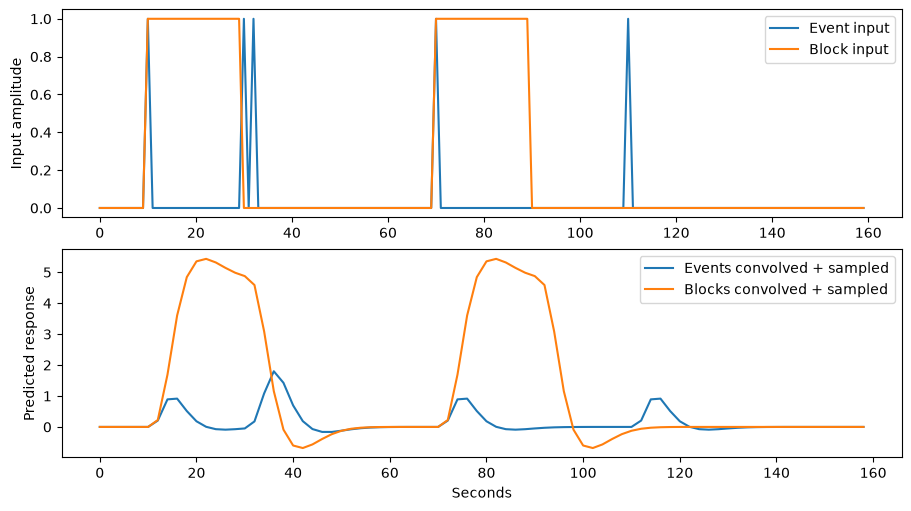

In [2]:
TR = 2
scan_times = seconds[::TR]
X = np.column_stack([pred_event[::TR], pred_block[::TR], np.ones(80)])
assert X.shape == (80, 3)
fig, ax = plt.subplots(2, 1, figsize=(9, 5), constrained_layout=True)
ax[0].plot(seconds, events, label='Event input'); ax[0].plot(seconds, blocks, label='Block input')
ax[0].set(ylabel='Input amplitude'); ax[0].legend()
ax[1].plot(scan_times, X[:, 0], label='Events convolved + sampled')
ax[1].plot(scan_times, X[:, 1], label='Blocks convolved + sampled')
ax[1].set(xlabel='Seconds', ylabel='Predicted response'); ax[1].legend(); plt.show()
wrong_sample = np.column_stack([events[::TR], blocks[::TR]])
assert not np.allclose(wrong_sample, X[:, :2])

## Supervise the AI, then transfer the idea

**AI prompt:** “Explain event log → input model → HRF convolution → scan-sampled design using named units. Ask me why the block response is larger. Give at most 15 lines to move an onset by two seconds and check which scan predictions change. State the HRF normalization and omitted physiology.”

**Deliberate mistake:** treat an onset of 30 seconds as scan index 30 when TR=2. Identify the resulting 60-second event. Then omit convolution and explain the temporal mismatch. For transfer, inspect BIDS events.tsv, duration conventions, retained volumes, slice-time reference, nuisance regressors, and the actual package HRF options. Deliver a plot with input and predicted response on a common time axis plus a table linking each design row to a scan. Choosing blocks versus events also depends on cognition, order effects, feasibility, and the desired estimand, not only response amplitude.

## Answer key — read after your own explanation

The illustrative HRF peaks after five seconds. Linear convolution of the summed inputs equals the sum of the separate predictions. With 160 seconds and TR=2, there are 80 rows. The sustained block integrates more input than one impulse, so the curves' heights alone do not compare design efficiency. Scan index 30 corresponds to second 60 here. Convolution predicts delayed hemodynamics; it does not directly measure neuronal timing.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Berkeley PSYCH214 syllabus, neural model and HRF topic](https://github.com/bic-berkeley/psych-214-fall-2016/blob/ec44652addc92091183456fa04fcd41dca0e172e/syllabus.rst); [DartBrains single-subject model, HRF convolution](https://github.com/ljchang/dartbrains/blob/b72537ad25deee0281248a415a052cd87ff325de/content/GLM_Single_Subject_Model.ipynb). See [the coverage and gaps](../../curriculum/design_coverage.md).